In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Optimize Data Loading: Copying Data to Local Storage

Reading data directly from Google Drive can be slow due to network latency and Google Drive's API limits. To significantly speed up data loading during training, it's recommended to copy the dataset to the Colab runtime's local file system (e.g., `/content/`) before training. This ensures that data access is much faster.

I will now add code to copy the `mnist_png` directory to `/content/` and then update the `data_dir` variable to use this local path. After this, you should re-run the data loading cell (`NOR6wfBpUcLd`) and then the training loop cell (`RuYJg1_9UqMN`).

In [13]:
import shutil
import time

# Define the destination path in Colab's local file system
local_data_dir = '/content/mnist_png'

print(f"Copying data from {data_dir} to {local_data_dir}...")
start_time = time.time()

# Remove existing directory if it exists to ensure a clean copy
if os.path.exists(local_data_dir):
    shutil.rmtree(local_data_dir)

# Copy the entire directory
shutil.copytree(data_dir, local_data_dir)

end_time = time.time()
print(f"Data copied successfully in {end_time - start_time:.2f} seconds.")

# Update data_dir to point to the local copy
data_dir = local_data_dir
print(f"Updated data_dir to: {data_dir}")

Copying data from /content/gdrive/MyDrive/Celebal Technologies/mnist_png to /content/mnist_png...
Data copied successfully in 1577.09 seconds.
Updated data_dir to: /content/mnist_png


In [14]:
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.4):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Generating random noise in normal distribution according to the size of tensor
        # Ensure noise is generated on the same device as the input tensor
        noise = torch.randn(tensor.size(), device=tensor.device) * self.std + self.mean
        # Adding noise directly to the pixel intensities
        noisy_tensor = tensor + noise
        # Bound the pixel values strictly back between [0.0, 1.0]
        return torch.clamp(noisy_tensor, 0.0, 1.0)


# Define transformations for reading raw images from drive
clean_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# 4. Use ImageFolder to map the subdirectories automatically
print("Loading datasets from Google Drive...")
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'training'), transform=clean_transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'testing'), transform=clean_transform)

# 5. Create DataLoaders to yield batches during training
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Successfully loaded {len(train_dataset)} training images and {len(test_dataset)} testing images!")

Loading datasets from Google Drive...
Successfully loaded 60016 training images and 10000 testing images!


In [15]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # 1. Encoder network
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # Out: 16 x 14 x 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Out: 32 x 7 x 7
            nn.ReLU()
        )

        # 2. Decoder network
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # Out: 16 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # Out: 1 x 28 x 28
            nn.Sigmoid()  # Compresses output pixel values strictly between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 10
noise_injector = AddGaussianNoise(mean=0.0, std=0.4) # Control noise intensity

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for clean_imgs, _ in train_loader:
        # Move clean target images to GPU/CPU
        clean_imgs = clean_imgs.to(device)

        # Generate the corrupted input images dynamically
        noisy_imgs = noise_injector(clean_imgs).to(device)

        # Standard PyTorch training sequence
        optimizer.zero_grad()
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs) # Target is the CLEAN image
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * clean_imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch}/{epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/10], Loss: 0.0334
Epoch [2/10], Loss: 0.0105
Epoch [3/10], Loss: 0.0098
Epoch [4/10], Loss: 0.0095
Epoch [5/10], Loss: 0.0094
Epoch [6/10], Loss: 0.0093
Epoch [7/10], Loss: 0.0092
Epoch [8/10], Loss: 0.0091
Epoch [9/10], Loss: 0.0090
Epoch [10/10], Loss: 0.0089


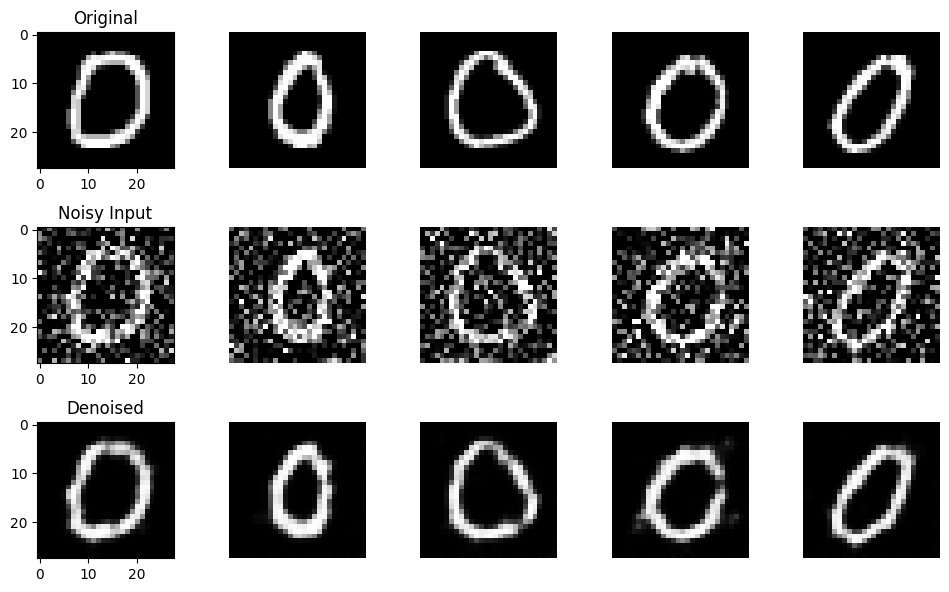

In [18]:
#Evaluating and doing Visual Verification
model.eval()
with torch.no_grad():
    # Grab one distinct batch from our unseen testing folder
    data_iter = iter(test_loader)
    test_clean, _ = next(data_iter)
    test_clean = test_clean.to(device)

    # Inject test noise and infer reconstruction
    test_noisy = noise_injector(test_clean).to(device)
    reconstructed = model(test_noisy)

# Convert tensors back to numpy arrays for plotting
test_clean = test_clean.cpu().numpy()
test_noisy = test_noisy.cpu().numpy()
reconstructed = reconstructed.cpu().numpy()

# Plot the top 5 images from each stage
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(10, 6))
for i in range(5):
    # Row 0: Original Clean Images
    axes[0, i].imshow(test_clean[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Original") if i==0 else axes[0, i].axis('off')

    # Row 1: Artificially Noisy Inputs
    axes[1, i].imshow(test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy Input") if i==0 else axes[1, i].axis('off')

    # Row 2: Model's Clean Denoised Output
    axes[2, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[2, i].set_title("Denoised") if i==0 else axes[2, i].axis('off')

plt.tight_layout()
plt.show()